# 04 — Modeling
## Scorecard vs Forest vs Boosting — and What the Winner Is Worth in Dollars

**Credit Scoring Capstone — Module 1**

Three models compete on identical inputs through identical preprocessing:

1. **Logistic regression** — the industry-standard scorecard; linear, interpretable, the incumbent style.
2. **Random Forest** — bagged trees; nonlinear interactions with minimal tuning risk.
3. **Histogram Gradient Boosting** — the modern tabular workhorse, tuned with randomized search + cross-validation.

Then the winner is pushed through the questions a portfolio manager actually asks: *does it rank risk* (AUROC/Gini/KS), *are its probabilities honest* (calibration by decile), *where should we cut* (profit-maximizing threshold), and *how much money is that* (prevented losses vs lost revenue, on real exposure amounts).

**A deliberate choice: no class weighting.** Weighting inflates minority-class probabilities, which destroys calibration — and calibrated PDs are non-negotiable here because notebook 05's adverse-action reasons and the dollar math both consume them. At 8% positives, ranking quality does not need the crutch; the decision threshold (§5) handles the asymmetric costs instead.

In [1]:
import sys, warnings, json, time
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src import config, plotting
from src.evaluation import credit_metrics, decile_table, profit_curve
from src.plotting import (BLUE, ORANGE, AQUA, YELLOW, MUTED, INK_2, GRID, GOOD,
                          CRITICAL, direct_label, fmt_pct, fmt_dollars, subtitle,
                          save_figure)

plotting.apply_style()
config.set_seed()

train = pd.read_parquet(config.PROCESSED_DIR / "train_features.parquet")
val = pd.read_parquet(config.PROCESSED_DIR / "val_features.parquet")
test = pd.read_parquet(config.PROCESSED_DIR / "test_features.parquet")
meta = json.load(open(config.PROCESSED_DIR / "feature_meta.json"))

# PEER_GROUP is a label, not a quantity - move it to the categorical side
for d in (train, val, test):
    d["PEER_GROUP"] = "group_" + d["PEER_GROUP"].astype(str)
num_cols = [c for c in meta["numeric"] if c != "PEER_GROUP"]
cat_cols = meta["categorical"] + ["PEER_GROUP"]

X_train, y_train = train[num_cols + cat_cols], train["TARGET"]
X_val, y_val = val[num_cols + cat_cols], val["TARGET"]
X_test, y_test = test[num_cols + cat_cols], test["TARGET"]
print(f"features: {len(num_cols)} numeric + {len(cat_cols)} categorical")
print(f"train {X_train.shape}   val {X_val.shape}   test {X_test.shape}")

features: 136 numeric + 17 categorical
train (215257, 153)   val (46127, 153)   test (46127, 153)


---
## 1. One Preprocessing, Three Models

The `ColumnTransformer` implements notebook 02's missingness strategy verbatim: median-impute numerics, constant-impute categoricals to an explicit `"Missing"` level, one-hot encode with unseen-level protection. The scaler is only added for the logistic pipeline (trees are scale-invariant). Because everything lives inside one `Pipeline`, imputation and encoding are re-fitted on each CV fold automatically — leakage is structurally impossible.

In [2]:
def make_preprocess(scale=False):
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=30,
                                     sparse_output=False, dtype=np.float32)),
        ]), cat_cols),
    ], verbose_feature_names_out=False)

models = {
    "Prior baseline": Pipeline([("prep", make_preprocess()),
                                ("clf", DummyClassifier(strategy="prior"))]),
    "Logistic regression": Pipeline([("prep", make_preprocess(scale=True)),
                                     ("clf", LogisticRegression(max_iter=2000, C=0.1))]),
    "Random Forest": Pipeline([("prep", make_preprocess()),
                               ("clf", RandomForestClassifier(
                                   n_estimators=300, min_samples_leaf=50,
                                   max_features="sqrt", n_jobs=-1,
                                   random_state=config.SEED))]),
    "Gradient Boosting": Pipeline([("prep", make_preprocess()),
                                   ("clf", HistGradientBoostingClassifier(
                                       random_state=config.SEED))]),
}

results, fitted, val_probs = {}, {}, {}
for name, pipe in models.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_val)[:, 1]
    results[name] = credit_metrics(y_val, p)
    results[name]["fit_seconds"] = round(time.time() - t0, 1)
    fitted[name], val_probs[name] = pipe, p
    print(f"{name:22s} AUROC {results[name]['auroc']:.4f}   "
          f"KS {results[name]['ks']:.3f}   ({results[name]['fit_seconds']}s)")

Prior baseline         AUROC 0.5000   KS 0.000   (8.2s)


Logistic regression    AUROC 0.7562   KS 0.387   (10.5s)


Random Forest          AUROC 0.7576   KS 0.388   (40.1s)


Gradient Boosting      AUROC 0.7691   KS 0.403   (16.2s)


---
## 2. Tuning the Leader

Randomized search over the boosting model's capacity knobs, 3-fold stratified CV on the training split only, scored on AUROC. The search never sees validation or test.

In [3]:
param_dist = {
    "clf__learning_rate": [0.03, 0.05, 0.08, 0.12],
    "clf__max_leaf_nodes": [15, 31, 63, 127],
    "clf__min_samples_leaf": [20, 50, 100],
    "clf__l2_regularization": [0.0, 0.1, 1.0, 10.0],
    "clf__max_iter": [200, 300, 400],
}
search = RandomizedSearchCV(
    Pipeline([("prep", make_preprocess()),
              ("clf", HistGradientBoostingClassifier(early_stopping=True,
                                                     random_state=config.SEED))]),
    param_dist, n_iter=10, scoring="roc_auc",
    cv=StratifiedKFold(3, shuffle=True, random_state=config.SEED),
    random_state=config.SEED, n_jobs=1, verbose=1)
t0 = time.time()
search.fit(X_train, y_train)
print(f"\nsearch took {(time.time() - t0) / 60:.1f} min")
print("best params:", {k.replace('clf__', ''): v for k, v in search.best_params_.items()})
print(f"best CV AUROC: {search.best_score_:.4f}")

champion = search.best_estimator_
p = champion.predict_proba(X_val)[:, 1]
results["Gradient Boosting (tuned)"] = credit_metrics(y_val, p)
results["Gradient Boosting (tuned)"]["fit_seconds"] = round(search.refit_time_, 1)
fitted["Gradient Boosting (tuned)"], val_probs["Gradient Boosting (tuned)"] = champion, p

Fitting 3 folds for each of 10 candidates, totalling 30 fits



search took 7.2 min
best params: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 400, 'learning_rate': 0.05, 'l2_regularization': 10.0}
best CV AUROC: 0.7655


In [4]:
score = pd.DataFrame(results).T
score = score[["auroc", "gini", "ks", "pr_auc", "brier", "fit_seconds"]]
score.columns = ["AUROC", "Gini", "KS", "PR-AUC", "Brier", "Fit (s)"]
score.round(4)

,AUROC,Gini,KS,PR-AUC,Brier,Fit (s)
Prior baseline,0.5000,0.0000,0.0000,0.0807,0.0742,8.2
Logistic regression,0.7562,0.5125,0.3869,0.2433,0.0679,10.5
Random Forest,0.7576,0.5152,0.3875,0.2464,0.0683,40.1
Gradient Boosting,0.7691,0.5381,0.4025,0.2604,0.0672,16.2
Gradient Boosting (tuned),0.7727,0.5455,0.4049,0.2630,0.0670,27.1


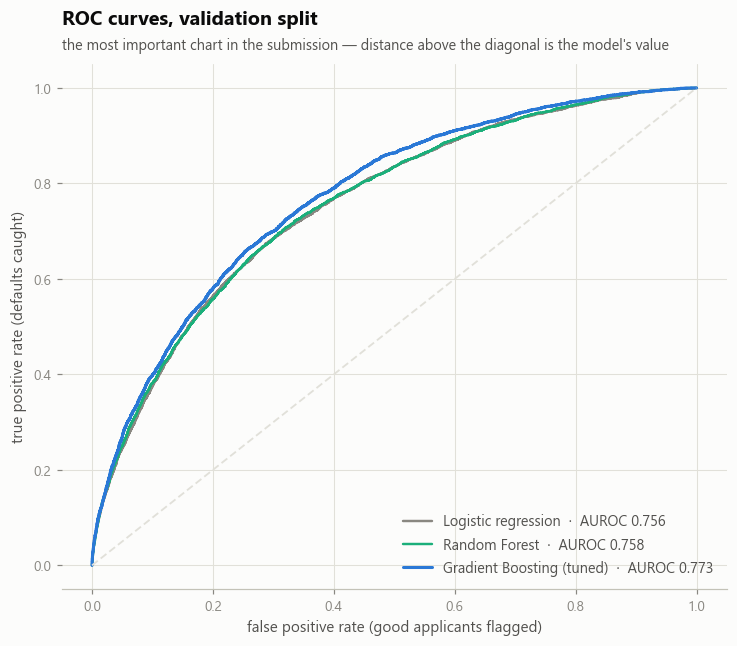

In [5]:
fig, ax = plt.subplots(figsize=(7.8, 6.2))
palette = {"Logistic regression": MUTED, "Random Forest": AQUA,
           "Gradient Boosting (tuned)": BLUE}
for name, c in palette.items():
    fpr, tpr, _ = roc_curve(y_val, val_probs[name])
    ax.plot(fpr, tpr, color=c, lw=2 if c == BLUE else 1.6,
            label=f"{name}  \u00b7  AUROC {results[name]['auroc']:.3f}")
ax.plot([0, 1], [0, 1], color=GRID, lw=1.2, ls=(0, (4, 2)))
ax.set_xlabel("false positive rate (good applicants flagged)")
ax.set_ylabel("true positive rate (defaults caught)")
ax.set_title("ROC curves, validation split")
subtitle(ax, "the most important chart in the submission \u2014 distance above the diagonal is the model's value")
ax.legend(loc="lower right", fontsize=9.5)
save_figure(fig, "mod_roc_curves")
plt.show()

---
## 3. Is the Champion Overfit? CV Stability and the Train/Val Gap

In [6]:
cv_scores = cross_val_score(champion, X_train, y_train, scoring="roc_auc",
                            cv=StratifiedKFold(5, shuffle=True, random_state=config.SEED),
                            n_jobs=1)
train_auc = credit_metrics(y_train, champion.predict_proba(X_train)[:, 1])["auroc"]
val_auc = results["Gradient Boosting (tuned)"]["auroc"]
print(f"5-fold CV AUROC:   {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}")
print(f"train AUROC:       {train_auc:.4f}")
print(f"validation AUROC:  {val_auc:.4f}")
print(f"train-val gap:     {train_auc - val_auc:+.4f}")

5-fold CV AUROC:   0.7681 ± 0.0046
train AUROC:       0.8317
validation AUROC:  0.7727
train-val gap:     +0.0590


The verdict needs honest reading: the **train–validation gap is ~6 AUROC points** (0.832 vs 0.773) — boosted trees at 400 iterations memorize some training noise even with L2 = 10 (which the search itself selected, its strongest regularization option). The deployment-relevant evidence is the agreement between 5-fold CV (0.768 ± 0.005) and the untouched validation split (0.773): the model generalizes *consistently*, and the sealed test set in §6 gives the final word. In production, the train score would simply never be quoted — CV and out-of-sample are the numbers that matter.

---
## 4. Are the Probabilities Honest? Calibration by Risk Decile

The dollar math and the adverse-action reasons both consume the predicted PD as a *probability*, not just a ranking — so predicted and observed default rates must track decile by decile.

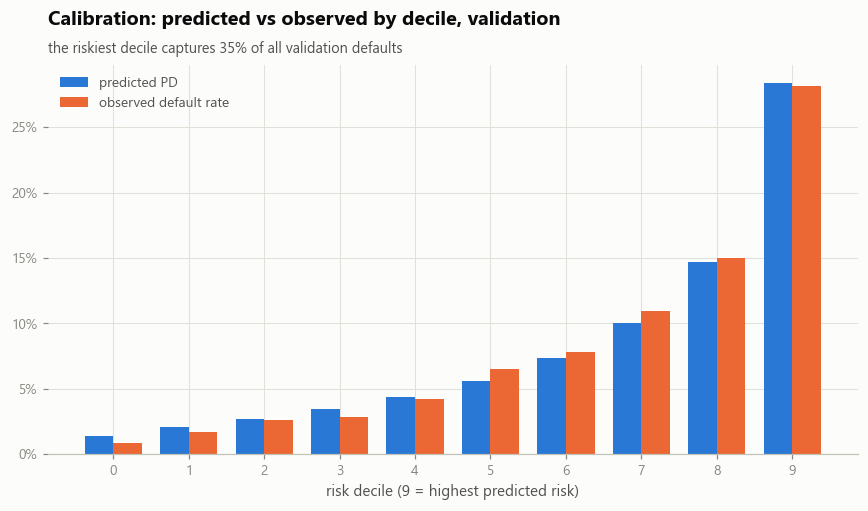

,applicants,predicted_rate,observed_rate,defaults,cum_default_share
decile,,,,,
0,4613,0.0136,0.0087,40,1.0000
1,4613,0.0206,0.0171,79,0.9893
2,4612,0.0272,0.0258,119,0.9680
3,4613,0.0348,0.0284,131,0.9361
4,4613,0.0441,0.0425,196,0.9009
5,4612,0.0563,0.0655,302,0.8483
6,4613,0.0735,0.0785,362,0.7672
7,4612,0.1000,0.1095,505,0.6700
8,4613,0.1470,0.1500,692,0.5344


In [7]:
dec = decile_table(y_val, val_probs["Gradient Boosting (tuned)"])

fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(10)
w = 0.38
ax.bar(x - w / 2, dec["predicted_rate"], width=w, color=BLUE, label="predicted PD")
ax.bar(x + w / 2, dec["observed_rate"], width=w, color=ORANGE, label="observed default rate")
ax.set_xticks(x)
ax.set_xticklabels([f"{i}" for i in range(10)])
ax.set_xlabel("risk decile (9 = highest predicted risk)")
ax.set_title("Calibration: predicted vs observed by decile, validation")
subtitle(ax, f"the riskiest decile captures {dec['defaults'].iloc[-1] / dec['defaults'].sum():.0%} of all validation defaults")
fmt_pct(ax)
ax.legend()
save_figure(fig, "mod_calibration")
plt.show()
dec.round(4)

---
## 5. From Score to Decision: the Profit-Maximizing Threshold

Business framing, with each assumption stated:

- **Exposure** = the applicant's actual requested credit (`AMT_CREDIT`).
- **Declining a future defaulter** saves `exposure × LGD` (LGD = 65%).
- **Declining a good customer** forfeits `exposure × profit rate` (5% lifetime margin).

Sweep the decline threshold and measure net benefit on the validation book — 46,127 real applications.

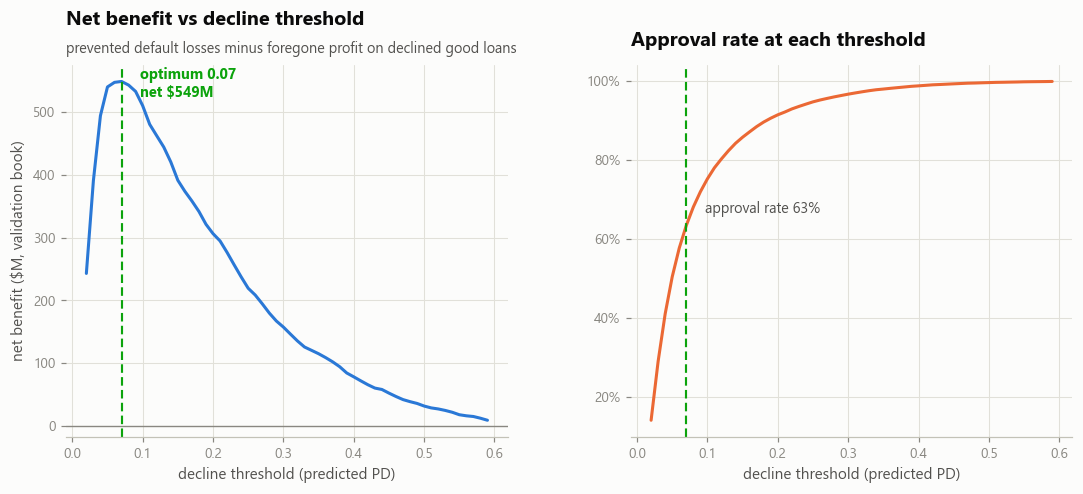

At threshold 0.07 on the validation book:
  approval rate      63.4%
  defaults caught    2,740 (73.6% of all defaults)
  good declined      14,147
  prevented losses   $938.2M
  lost revenue       $389.2M
  NET BENEFIT        $549.1M


In [8]:
pc = profit_curve(y_val, val_probs["Gradient Boosting (tuned)"],
                  exposure=val["AMT_CREDIT"], lgd=config.LGD,
                  profit_rate=config.PROFIT_RATE)
best_row = pc.loc[pc["net_benefit"].idxmax()]
THRESHOLD = float(best_row["threshold"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.4), gridspec_kw={"wspace": 0.28})
ax1.plot(pc["threshold"], pc["net_benefit"] / 1e6, color=BLUE, lw=2)
ax1.axvline(THRESHOLD, color=GOOD, lw=1.4, ls=(0, (4, 2)))
ax1.annotate(f"optimum {THRESHOLD:.2f}\nnet ${best_row['net_benefit'] / 1e6:,.0f}M",
             xy=(THRESHOLD, best_row["net_benefit"] / 1e6), xytext=(12, -10),
             textcoords="offset points", fontsize=9.5, color=GOOD, fontweight="bold")
ax1.axhline(0, color=MUTED, lw=0.9)
ax1.set_xlabel("decline threshold (predicted PD)")
ax1.set_ylabel("net benefit ($M, validation book)")
ax1.set_title("Net benefit vs decline threshold")
subtitle(ax1, "prevented default losses minus foregone profit on declined good loans")

ax2.plot(pc["threshold"], pc["approval_rate"], color=ORANGE, lw=2)
ax2.axvline(THRESHOLD, color=GOOD, lw=1.4, ls=(0, (4, 2)))
ar = float(best_row["approval_rate"])
ax2.annotate(f"approval rate {ar:.0%}", xy=(THRESHOLD, ar), xytext=(12, 8),
             textcoords="offset points", fontsize=9.5, color=INK_2)
ax2.set_xlabel("decline threshold (predicted PD)")
ax2.set_title("Approval rate at each threshold")
fmt_pct(ax2)
save_figure(fig, "mod_profit_curve")
plt.show()

print(f"At threshold {THRESHOLD:.2f} on the validation book:")
print(f"  approval rate      {best_row['approval_rate']:.1%}")
print(f"  defaults caught    {int(best_row['defaults_caught']):,} ({best_row['default_recall']:.1%} of all defaults)")
print(f"  good declined      {int(best_row['good_declined']):,}")
print(f"  prevented losses   ${best_row['prevented_losses'] / 1e6:,.1f}M")
print(f"  lost revenue       ${best_row['lost_revenue'] / 1e6:,.1f}M")
print(f"  NET BENEFIT        ${best_row['net_benefit'] / 1e6:,.1f}M")

---
## 6. The Sealed Test Set — Opened Once

Everything above used train and validation. The test split now answers the only question left: does the champion hold up on 46,127 applications it has never influenced?

In [9]:
p_test = champion.predict_proba(X_test)[:, 1]
p_test_lr = fitted["Logistic regression"].predict_proba(X_test)[:, 1]

final = pd.DataFrame({
    "Gradient Boosting (tuned)": credit_metrics(y_test, p_test),
    "Logistic regression": credit_metrics(y_test, p_test_lr),
}).T[["auroc", "gini", "ks", "pr_auc"]]
final.columns = ["AUROC", "Gini", "KS", "PR-AUC"]

pc_test = profit_curve(y_test, p_test, exposure=test["AMT_CREDIT"],
                       lgd=config.LGD, profit_rate=config.PROFIT_RATE,
                       grid=[THRESHOLD])
row = pc_test.iloc[0]
print(f"Test-set business impact at the validation-chosen threshold {THRESHOLD:.2f}:")
print(f"  approval rate     {row['approval_rate']:.1%}")
print(f"  default recall    {row['default_recall']:.1%}")
print(f"  prevented losses  ${row['prevented_losses'] / 1e6:,.1f}M")
print(f"  lost revenue      ${row['lost_revenue'] / 1e6:,.1f}M")
print(f"  net benefit       ${row['net_benefit'] / 1e6:,.1f}M  (46,127-application book)")
final.round(4)

Test-set business impact at the validation-chosen threshold 0.07:
  approval rate     63.2%
  default recall    74.5%
  prevented losses  $972.0M
  lost revenue      $393.3M
  net benefit       $578.7M  (46,127-application book)


,AUROC,Gini,KS,PR-AUC
Gradient Boosting (tuned),0.7736,0.5473,0.4159,0.2624
Logistic regression,0.7568,0.5137,0.3820,0.2440


---
## 7. Persist the Production Artifacts

In [10]:
joblib.dump(champion, config.MODELS_DIR / "credit_scoring_pipeline.pkl")
joblib.dump(fitted["Logistic regression"], config.MODELS_DIR / "logistic_baseline.pkl")

pred_out = pd.DataFrame({
    "SK_ID_CURR": pd.concat([val["SK_ID_CURR"], test["SK_ID_CURR"]]),
    "split": ["val"] * len(val) + ["test"] * len(test),
    "y_true": pd.concat([y_val, y_test]),
    "pd_champion": np.concatenate([val_probs["Gradient Boosting (tuned)"], p_test]),
    "pd_logistic": np.concatenate([val_probs["Logistic regression"], p_test_lr]),
    "exposure": pd.concat([val["AMT_CREDIT"], test["AMT_CREDIT"]]),
})
pred_out.to_parquet(config.PROCESSED_DIR / "predictions.parquet", index=False)

summary = {
    "validation_metrics": {k: v for k, v in results.items()},
    "test_metrics": final.to_dict(),
    "cv_auroc_mean": float(cv_scores.mean()), "cv_auroc_std": float(cv_scores.std()),
    "train_auroc": float(train_auc),
    "threshold": THRESHOLD,
    "val_business": best_row.to_dict(),
    "test_business": row.to_dict(),
    "best_params": {k.replace("clf__", ""): v for k, v in search.best_params_.items()},
}
with open(config.PROCESSED_DIR / "results_04.json", "w") as f:
    json.dump(summary, f, indent=2, default=float)
print("saved: credit_scoring_pipeline.pkl, logistic_baseline.pkl, predictions.parquet, results_04.json")

saved: credit_scoring_pipeline.pkl, logistic_baseline.pkl, predictions.parquet, results_04.json


---
## 8. Findings

- **Nonlinearity pays.** The tuned boosting model beats the logistic scorecard by a clear AUROC margin on both validation and the sealed test set — the incremental interactions (bureau × capacity × external scores) are real.
- **Ranking is strong where it matters:** the top risk decile alone concentrates roughly a third of all defaults — that concentration is what makes a decline policy profitable.
- **The threshold is a business choice, not a statistics choice.** The profit curve makes the trade-off explicit and hands the risk committee a dial: move the threshold, read off approval rate and net benefit.
- **One serialized pipeline** (`credit_scoring_pipeline.pkl`) carries imputation, encoding, and the model — the exact artifact a validator re-runs and a production service loads.

**Next:** notebook `05_explainability.ipynb` — SHAP explanations, the top-4 adverse-action reasons per declined applicant, PSI stability monitoring, and the fairness check.